# Linear Regression — Supervised Learning

Linear regression finds the best straight line through data to predict a continuous output from one or more inputs. It's one of the most widely used algorithms in ML.

**Common use cases:** exam score prediction, salary estimation, house pricing, stock forecasting, crop yield estimation.

## The Best-Fit Line

The goal is to find the line **y = mx + b** that comes closest to all data points:
- **m** (slope) — how much y changes per unit increase in x
- **b** (intercept) — value of y when x = 0

Example: if salary = 5000 × experience + 30000, the slope means each extra year of experience is worth $5,000.

> Limitations: assumes a linear relationship, and is sensitive to outliers.

## Least Squares Method

A **residual** is the gap between actual and predicted: $\text{residual}_i = y_i - \hat{y}_i$

The least squares method minimizes $\sum(y_i - \hat{y}_i)^2$ — we square the differences so positives and negatives don't cancel, and larger errors are penalized more heavily. The slope and intercept that minimize this sum give us the best-fit line.

## Hypothesis Function

**Simple (one variable):** $h(x) = \beta_0 + \beta_1 x$

**Multiple (k variables):** $h(x_1,...,x_k) = \beta_0 + \beta_1 x_1 + ... + \beta_k x_k$

Each $\beta_k$ is a coefficient showing how much that variable influences the output. Simple regression draws a line; multiple regression fits a plane or hyperplane.

## Types of Linear Regression

**Simple (univariate):** one input → one output. Formula: $\hat{y} = \theta_0 + \theta_1 x$. Example: salary from years of experience.

**Multiple (multivariate):** two or more inputs. Formula: $\hat{y} = \theta_0 + \theta_1 x_1 + ... + \theta_n x_n$. Example: house price from size, location, and age.

| Industry | Inputs | Output |
|---|---|---|
| Real Estate | Location, size, condition | Price |
| Finance | Interest rates, inflation | Stock price |
| Agriculture | Rainfall, temperature, soil | Crop yield |
| E-Commerce | Price, promotions, season | Sales |

## 7 Assumptions of Linear Regression

1. **Linearity** — X and Y have a straight-line relationship
2. **Independence of Errors** — residuals don't influence each other
3. **Homoscedasticity** — error spread is constant across X values; the violation (unequal spread) is called heteroscedasticity
4. **Normality of Errors** — residuals follow a bell-shaped distribution
5. **No Multicollinearity** — input variables shouldn't be highly correlated with each other
6. **No Autocorrelation** — errors don't repeat in a pattern (important in time-series)
7. **Additivity** — each feature's effect on Y is independent; total effect = sum of individual effects

## Cost Function

The cost function measures how wrong our predictions are. For linear regression we use **Mean Squared Error**:

$$J(\theta) = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2 \quad \text{where } \hat{y}_i = \theta_1 + \theta_2 x_i$$

Training = finding the $\theta$ values that make $J(\theta)$ as small as possible. Squaring keeps all values positive and punishes big errors harder.

## Gradient Descent

Gradient descent is the algorithm that minimizes $J(\theta)$ by iteratively adjusting slope and intercept:

1. Start with random values for $\theta_0$ and $\theta_1$
2. Compute prediction error using current parameters
3. Calculate the gradient (how much each parameter contributes to the error)
4. Update: $\theta_j := \theta_j - \alpha \frac{\partial J}{\partial \theta_j}$ (α = learning rate)
5. Repeat until error stops decreasing (convergence)

> Note: sklearn's `LinearRegression` uses the Normal Equation (exact closed-form solution) for small datasets, not gradient descent — but the concept is the same.

## Imports

In [1]:
import numpy as np                          # arrays and math
import matplotlib.pyplot as plt             # plotting
from sklearn.linear_model import LinearRegression          # the model
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score  # evaluation
import warnings
warnings.filterwarnings('ignore')           # keep output clean

## Step 1 — Generate the Dataset

No real dataset here — we'll generate synthetic data with a known linear relationship (Y ≈ 3.5X) plus some noise to simulate real-world messiness. The seed makes the results reproducible.

In [2]:
np.random.seed(42)                          # fix seed for reproducibility

X = np.random.rand(50, 1) * 100            # 50 random X values between 0 and 100
Y = 3.5 * X + np.random.randn(50, 1) * 20  # Y = 3.5X + noise

print("Shape of X:", X.shape)              # (50, 1) — 50 samples, 1 feature
print("Shape of Y:", Y.shape)              # (50, 1) — 50 samples, 1 target

print(f"\n{'X':>12}  {'Y':>12}")
print("-" * 27)
for i in range(5):                         # preview first 5 rows
    print(f"{X[i, 0]:>12.4f}  {Y[i, 0]:>12.4f}")

Shape of X: (50, 1)
Shape of Y: (50, 1)

           X             Y
---------------------------
     37.4540      145.8584
     95.0714      336.1774
     73.1994      253.8849
     59.8658      203.5084
     15.6019       25.0361


## Step 2 — Visualize Raw Data

Always look at the data before modeling. This confirms the relationship looks linear and helps spot any outliers or unexpected patterns.

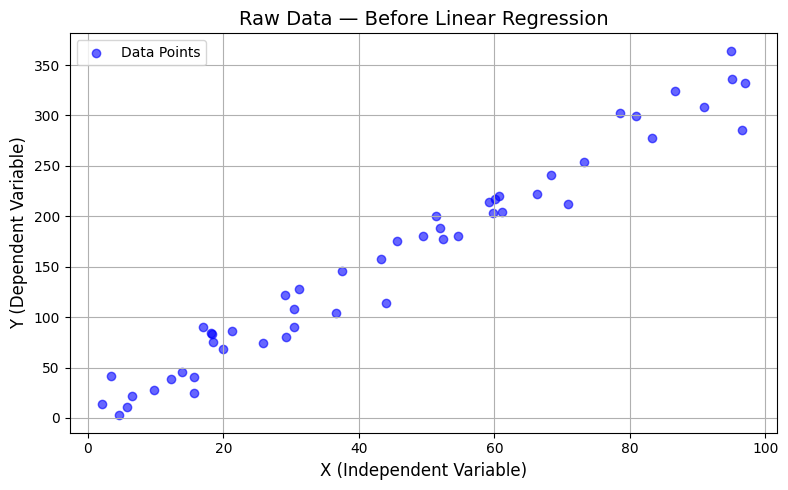

In [3]:
plt.figure(figsize=(8, 5))
plt.scatter(X, Y, color='blue', alpha=0.6, label='Data Points')  # plot raw data
plt.title('Raw Data — Before Linear Regression', fontsize=14)
plt.xlabel('X (Independent Variable)', fontsize=12)
plt.ylabel('Y (Dependent Variable)', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Step 3 — Train the Model

`model.fit(X, Y)` uses the Least Squares method to find the slope and intercept that minimize total squared error across all 50 points.

In [4]:
model = LinearRegression()                  # create an untrained model
model.fit(X, Y)                             # train: find best slope and intercept

slope = model.coef_[0][0]                  # learned slope
intercept = model.intercept_[0]            # learned intercept

print(f"Slope     (m): {slope:.4f}")
print(f"Intercept (b): {intercept:.4f}")
print(f"\nFor every 1-unit increase in X, Y increases by ~{slope:.2f}.")
print(f"When X = 0, predicted Y ≈ {intercept:.2f}.")
print(f"True slope was 3.5 — model learned: {slope:.2f}")

Slope     (m): 3.4553
Intercept (b): 1.9338

For every 1-unit increase in X, Y increases by ~3.46.
When X = 0, predicted Y ≈ 1.93.
True slope was 3.5 — model learned: 3.46


## Step 4 — Make Predictions

`model.predict(X)` applies the learned formula $\hat{y} = mx + b$ to every X value and returns the predicted Y.

In [5]:
Y_pred = model.predict(X)                  # predict Y for all X values

print(f"{'Index':>6}  {'Actual Y':>12}  {'Predicted Y':>12}  {'Residual':>12}")
print("-" * 50)
for i in range(5):                         # show first 5 actual vs. predicted
    actual = Y[i, 0]
    predicted = Y_pred[i, 0]
    print(f"{i:>6}  {actual:>12.4f}  {predicted:>12.4f}  {actual - predicted:>12.4f}")

 Index      Actual Y   Predicted Y      Residual
--------------------------------------------------
     0      145.8584      131.3491       14.5092
     1      336.1774      330.4354        5.7420
     2      253.8849      254.8606       -0.9757
     3      203.5084      208.7890       -5.2806
     4       25.0361       55.8431      -30.8070


## Step 5 — Visualize the Regression Line

The red line is what the model learned. It should cut through the middle of the data cloud — that's the best-fit line.

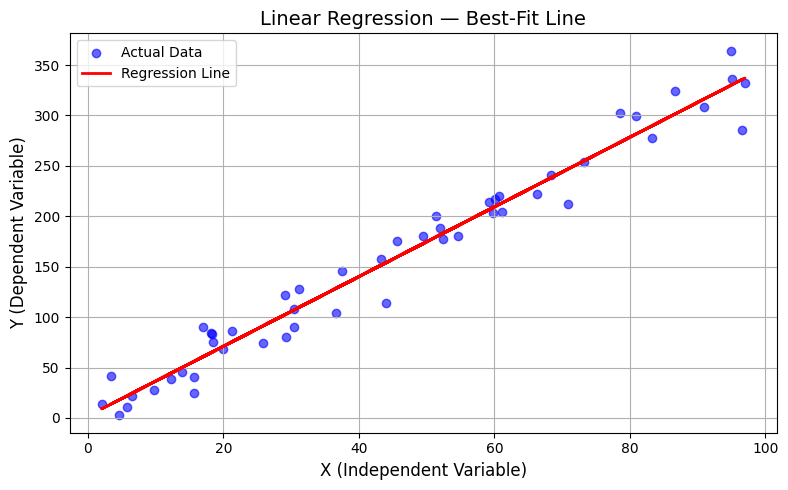

In [6]:
plt.figure(figsize=(8, 5))
plt.scatter(X, Y, color='blue', alpha=0.6, label='Actual Data')          # original data
plt.plot(X, Y_pred, color='red', linewidth=2, label='Regression Line')   # fitted line
plt.title('Linear Regression — Best-Fit Line', fontsize=14)
plt.xlabel('X (Independent Variable)', fontsize=12)
plt.ylabel('Y (Dependent Variable)', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Evaluation Metrics

- **MSE** — average squared error; penalizes large errors heavily (units are Y²)
- **MAE** — average absolute error; easier to interpret, same unit as Y
- **RMSE** — square root of MSE; same unit as Y, most intuitive to report
- **R²** — how much variance in Y the model explains (0 to 1, higher is better)
- **Adjusted R²** — like R² but penalizes adding irrelevant features; better for multiple regression

In [7]:
mse  = mean_squared_error(Y, Y_pred)       # average squared prediction error
mae  = mean_absolute_error(Y, Y_pred)      # average absolute prediction error
rmse = np.sqrt(mse)                        # same unit as Y
r2   = r2_score(Y, Y_pred)                # variance explained by the model

n = X.shape[0]                             # number of samples
k = X.shape[1]                             # number of features
adj_r2 = 1 - ((1 - r2) * (n - 1)) / (n - k - 1)  # adjusted R² formula

print("=" * 40)
print("       MODEL EVALUATION METRICS")
print("=" * 40)
print(f"  MSE            : {mse:.4f}")
print(f"  MAE            : {mae:.4f}")
print(f"  RMSE           : {rmse:.4f}")
print(f"  R²             : {r2:.4f}")
print(f"  Adjusted R²    : {adj_r2:.4f}")
print("=" * 40)

       MODEL EVALUATION METRICS
  MSE            : 329.2285
  MAE            : 14.6128
  RMSE           : 18.1447
  R²             : 0.9674
  Adjusted R²    : 0.9667


## Regularization Techniques

Standard linear regression can overfit — it memorizes the training data instead of generalizing. Regularization adds a penalty to the cost function to keep coefficients small.

- **Lasso (L1):** penalizes the sum of absolute coefficients → can shrink some to exactly zero (built-in feature selection)
- **Ridge (L2):** penalizes the sum of squared coefficients → shrinks all toward zero but never to zero; handles multicollinearity well
- **Elastic Net:** combines L1 and L2 → best of both; good when you have many features and aren't sure which type to use

## Advantages & Limitations

**Advantages:**
- Simple and interpretable — slope and intercept have clear real-world meaning
- Computationally efficient, scales to large datasets
- Good baseline: if a complex model barely beats it, the added complexity may not be worth it
- Supported in every major ML library

**Limitations:**
- Assumes a linear relationship — fails on curved or complex data
- Sensitive to multicollinearity between features
- Requires feature engineering for messy real-world data
- Can overfit or underfit without regularization
- Not suitable when there are strong interactions between features